<a href="https://colab.research.google.com/github/ankitadalvi133/CSL701-CE05_Machine-Learning-Lab/blob/main/Experiment_02_Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Ankita Ashok Dalvi

Roll No : CE05

Batch : CE01

Experiment NO : 02

Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

TASK 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TASK 2 — Load the Auto MPG Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving auto-mpg.csv to auto-mpg.csv


In [ ]:
df = pd.read_csv('auto-mpg.csv')

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


TASK 3 — Inspect the Dataset

In [ ]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset information:")
df.info()

Shape of dataset: (398, 9)

Column names:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino



Last 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


TASK 4 — Check for Missing Values

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


TASK 5 — Select Horsepower and MPG

In [ ]:
X = df[['horsepower']]
y = df['mpg']

print("X (Horsepower):")
display(X.head())

print("\ny (MPG):")
display(y.head())

X (Horsepower):


,horsepower
0,130
1,165
2,150
3,150
4,140



y (MPG):


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


TASK 6 — Basic EDA

In [ ]:
print("Descriptive Statistics:")
display(df[['horsepower', 'mpg']].describe())

Descriptive Statistics:


,mpg
count,398.000000
mean,23.514573
std,7.815984
min,9.000000
25%,17.500000
50%,23.000000
75%,29.000000
max,46.600000


In [ ]:
print(df[['horsepower', 'mpg']].dtypes)

horsepower     object
mpg           float64
dtype: object


TASK 8.5 — Clean Horsepower Column

Based on the error, the `horsepower` column contains non-numeric values ('?'). We need to replace these with `NaN` and convert the column to a numeric type.

In [ ]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'])

print("Missing values after cleaning horsepower:")
print(df.isnull().sum())

In [ ]:
# Since we are predicting MPG, rows with missing 'horsepower' should be removed if 'horsepower' is the feature.
df.dropna(inplace=True)

print("\nShape of dataset after dropping NaNs:", df.shape)
print("First 5 rows after cleaning and dropping NaNs:")
display(df.head())

In [ ]:
# Re-select X and y after cleaning
X = df[['horsepower']]
y = df['mpg']

print("X (Horsepower) after cleaning:")
display(X.head())

TASK 7 — Scatter Plot

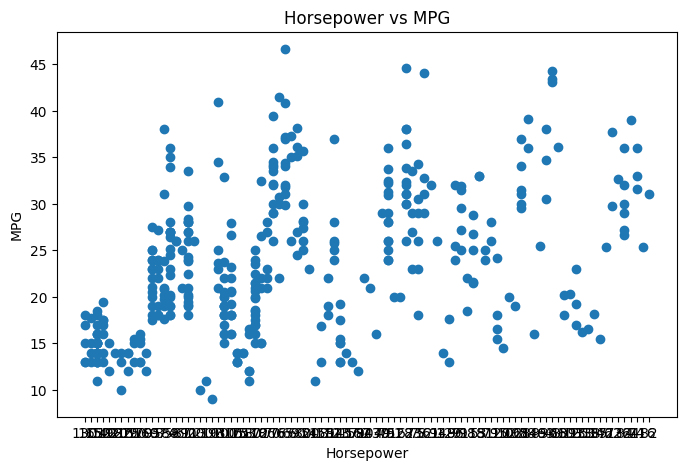

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df['horsepower'], df['mpg'])

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Horsepower vs MPG')

plt.show()

TASK 8 — Add Bias Term

In [ ]:
X_ols = np.column_stack((np.ones(len(X)), X['horsepower']))

print("First 5 rows of X with bias term:")
print(X_ols[:5])

First 5 rows of X with bias term:
[[1.0 '130']
 [1.0 '165']
 [1.0 '150']
 [1.0 '150']
 [1.0 '140']]


The first column containing 1 is the bias/intercept term.

So our model is:
MPG = b0 + b1 × Horsepower

where:

b0 = intercept
b1 = slope

TASK 9 — Calculate Correlation

In [ ]:
# Replace '?' with NaN
df['horsepower'] = df['horsepower'].replace('?', np.nan)

# Convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'])

# Remove rows where horsepower is missing
df = df.dropna(subset=['horsepower'])

# Calculate correlation
correlation = df['horsepower'].corr(df['mpg'])

print("Correlation between Horsepower and MPG:", correlation)

Correlation between Horsepower and MPG: -0.7784267838977756


TASK 10 — Calculate OLS Weights

The OLS normal equation is:

β = (XᵀX)⁻¹ XᵀY

In [ ]:
# Make a copy and clean horsepower
df = df.copy()
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower'])

# X = Horsepower, y = MPG
X = df['horsepower'].values
y = df['mpg'].values

# Add intercept column
X_ols = np.column_stack((np.ones(len(X)), X))

# Calculate OLS coefficients
beta = np.linalg.lstsq(X_ols, y, rcond=None)[0]

# Display results
print("Intercept:", beta[0])
print("Slope:", beta[1])
print(f"Regression Equation: MPG = {beta[0]:.4f} + ({beta[1]:.4f}) × Horsepower")

Intercept: 39.93586102117048
Slope: -0.15784473335365373
Regression Equation: MPG = 39.9359 + (-0.1578) × Horsepower


TASK 11 — Predict MPG

In [ ]:
# Predict MPG using the OLS coefficients
y_pred = X_ols @ beta

print("First 10 actual MPG values:")
print(y[:10])

print("\nFirst 10 predicted MPG values:")
print(y_pred[:10])

First 10 actual MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

First 10 predicted MPG values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


TASK 12 — Calculate Residuals

In [ ]:
# Calculate residuals
residuals = y - y_pred

print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


The formula is :

Residual=Actual−Predicted

TASK 13 — Calculate SSE, MSE and R²

In [ ]:
# Calculate SSE
SSE = np.sum(residuals ** 2)

# Calculate MSE
MSE = np.mean(residuals ** 2)

# Calculate R²
SS_total = np.sum((y - np.mean(y)) ** 2)
R2 = 1 - (SSE / SS_total)

print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)

SSE: 9385.915871932417
MSE: 23.943662938603104
R²: 0.6059482578894351


Task 14 : Plot regression and residual graphs

1. Plot Regression Graph

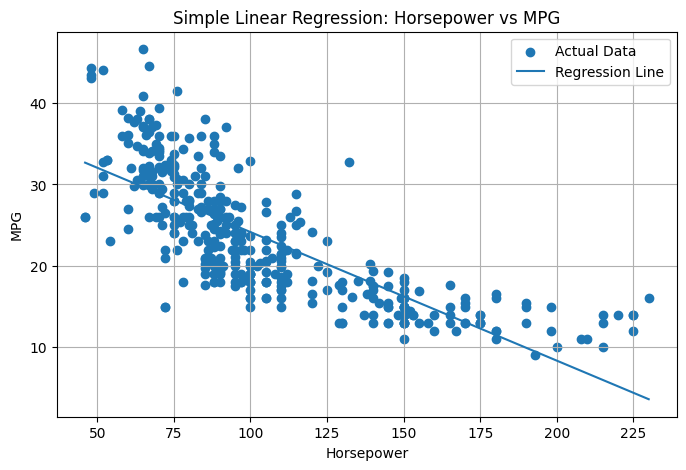

In [ ]:
# Sort horsepower values for a smooth regression line
sorted_indices = np.argsort(X)

X_sorted = X[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Plot actual data
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label='Actual Data')

# Plot regression line
plt.plot(X_sorted, y_pred_sorted, label='Regression Line')

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Simple Linear Regression: Horsepower vs MPG')
plt.legend()
plt.grid(True)

plt.show()

2. Plot Residual Graph

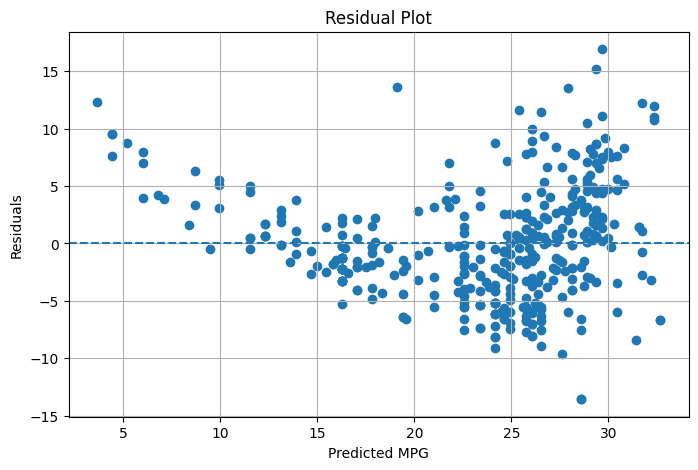

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

# Reference line at residual = 0
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted MPG')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)

plt.show()

Task 15 : Interpret the Results



The Simple Linear Regression model was implemented using the Ordinary Least Squares (OLS) method to predict MPG from Horsepower.

The correlation between Horsepower and MPG is negative, indicating an inverse relationship between the two variables. As Horsepower increases, MPG generally decreases.

The calculated slope of the regression model is negative, which further confirms the negative relationship between Horsepower and MPG.

The regression line shows the overall relationship between Horsepower and MPG. The residual plot shows the differences between the actual and predicted MPG values.

The model was evaluated using SSE, MSE and R². These metrics help measure the prediction error and the goodness of fit of the regression model.

In [ ]:
print("========== FINAL RESULTS ==========")

print(f"Correlation: {correlation:.4f}")

print(f"Intercept: {beta[0]:.4f}")
print(f"Slope: {beta[1]:.4f}")

print(f"Regression Equation:")
print(f"MPG = {beta[0]:.4f} + ({beta[1]:.4f}) × Horsepower")

print(f"\nSSE: {SSE:.4f}")
print(f"MSE: {MSE:.4f}")
print(f"R²: {R2:.4f}")

========== FINAL RESULTS ==========
Correlation: -0.7784
Intercept: 39.9359
Slope: -0.1578
Regression Equation:
MPG = 39.9359 + (-0.1578) × Horsepower

SSE: 9385.9159
MSE: 23.9437
R²: 0.6059


Conclusion :

The experiment successfully implemented Simple Linear Regression using the Ordinary Least Squares (OLS) method. The Auto MPG dataset was loaded and preprocessed, and Horsepower was used as the independent variable to predict MPG. The OLS coefficients were calculated and used to obtain predicted MPG values. SSE, MSE and R² were calculated to evaluate the model. Regression and residual plots were also generated. The results showed a negative relationship between Horsepower and MPG.